# MaplePulse — LangGraph Focus Group Pipeline

Synthetic focus group powered by LangGraph with intent classification and optimization loop.

**Architecture**:
```
START → classify_intent → select_panel → run_reactions → aggregate
  → optimize_message → run_reactions_v2 → aggregate_v2 (before/after comparison) → END
```

**Optimization loop**: Round 1 reactions feed into an LLM optimizer that rewrites the message,
then the same panel re-evaluates the improved version. The final output is a before/after comparison.

**Stack**: LangGraph (orchestration) → OpenRouter (LLM) → Langfuse (observability)

## 1. Setup & Dependencies

In [1]:
import os, json, random, time, uuid, asyncio, operator
from pathlib import Path
from typing import Annotated, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field

load_dotenv(Path("../.env"))

print(f"OpenRouter key: {'yes' if os.environ.get('OPENROUTER_API_KEY') else 'NO'}")
print(f"Langfuse key:   {'yes' if os.environ.get('LANGFUSE_SECRET_KEY') else 'NO'}")

OpenRouter key: yes
Langfuse key:   yes


In [2]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END

DEFAULT_MODEL = "openai/gpt-5-mini"

def build_model(model_name: str = DEFAULT_MODEL, temperature: float = 0.7) -> ChatOpenAI:
    return ChatOpenAI(
        model=model_name,
        base_url="https://openrouter.ai/api/v1",
        api_key=os.environ["OPENROUTER_API_KEY"],
        temperature=temperature,
    )

llm = build_model()
resp = llm.invoke("Say 'MaplePulse is alive' in exactly those words.")
print(f"Model: {DEFAULT_MODEL}")
print(f"Response: {resp.content}")

Model: openai/gpt-5-mini
Response: MaplePulse is alive


## 2. Langfuse Observability

In [3]:
from langfuse import Langfuse
from langfuse.langchain import CallbackHandler as LangfuseCallbackHandler

lf = Langfuse()

def make_langfuse_handler(trace_id: str = None) -> LangfuseCallbackHandler:
    """Create a Langfuse callback handler for LangGraph (v4 API).
    
    Pass to graph.ainvoke(..., config={"callbacks": [handler]})
    LangGraph propagates it to all nodes + LLM calls automatically.
    
    For session/metadata, wrap the graph call in:
        with lf.start_as_current_observation(name=..., metadata=...):
            handler = make_langfuse_handler()
            result = await graph.ainvoke(..., config={"callbacks": [handler]})
    """
    ctx = {"trace_id": trace_id} if trace_id else None
    return LangfuseCallbackHandler(trace_context=ctx)

# Quick auth check
try:
    lf.auth_check()
    print(f"Langfuse v4 connected — host: {os.environ.get('LANGFUSE_HOST', 'default')}")
    print("Auth check: OK")
    print("Tracing: will use start_as_current_observation + CallbackHandler")
except Exception as e:
    print(f"Langfuse auth FAILED: {e}")
    print("Traces will NOT be sent — check LANGFUSE_SECRET_KEY and LANGFUSE_PUBLIC_KEY in .env")

Langfuse v4 connected — host: default
Auth check: OK
Tracing: will use start_as_current_observation + CallbackHandler


## 3. Load Personas & Panel Selection

In [4]:
PERSONAS_PATH = Path("../data/personas_5000.json")

with open(PERSONAS_PATH, "r", encoding="utf-8") as f:
    ALL_PERSONAS = json.load(f)

print(f"Loaded {len(ALL_PERSONAS):,} personas | {len(ALL_PERSONAS[0])} fields each")


def select_panel(
    n: int = 20,
    province: str | None = None,
    age_range: tuple[int, int] | None = None,
    income_bracket: str | None = None,
    seed: int = 42,
) -> list[dict]:
    pool = ALL_PERSONAS
    if province:
        pool = [p for p in pool if p["province"] == province]
    if age_range:
        pool = [p for p in pool if age_range[0] <= p["age"] <= age_range[1]]
    if income_bracket:
        pool = [p for p in pool if p.get("income_bracket") == income_bracket]
    rng = random.Random(seed)
    return rng.sample(pool, min(n, len(pool)))


def build_persona_context(persona: dict) -> str:
    concerns = ", ".join(persona.get("top_concerns", []))
    income = persona.get("estimated_annual_income")
    income_str = f"${income:,}/yr ({persona.get('income_bracket', 'Unknown')})" if income else persona.get("income_bracket", "Unknown")
    return (
        f"Age: {persona['age']} | Sex: {persona['sex']} | Province: {persona['province']}\n"
        f"City/Region: {persona['planning_area']}\n"
        f"Occupation: {persona['occupation']} | Education: {persona['education_level']}\n"
        f"Income: {income_str}\n"
        f"Housing: {persona['housing']}\n"
        f"Marital status: {persona['marital_status']}\n"
        f"Immigration: {persona['immigration_status']} | Indigenous: {persona['indigenous_identity']}\n"
        f"Visible minority: {persona['visible_minority']} | Cultural background: {persona['cultural_background']}\n"
        f"Languages: {persona['languages_spoken']}\n"
        f"Political leaning: {persona['political_leaning']} | Religion: {persona['religion']}\n"
        f"Top concerns: {concerns}\n"
        f"Commute: {persona['commute_mode']}"
    )

print("Panel selection & persona context ready")
print("  - select_panel now supports income_bracket filter")
print("  - build_persona_context now shows actual income instead of housing proxy")

Loaded 5,000 personas | 25 fields each
Panel selection & persona context ready
  - select_panel now supports income_bracket filter
  - build_persona_context now shows actual income instead of housing proxy


## 4. Graph State & Schemas

The shared state flows through every node. The classification node sets `use_case`, then the router sends it to the right branch.

In [5]:
from typing import TypedDict

# --- Graph State ---
class FocusGroupState(TypedDict):
    """Shared state that flows through the entire graph."""
    # Input
    user_input: str                    # Raw user input (concept, copy, question, message)
    panel_size: int                    # How many personas to sample
    panel_seed: int                    # Random seed for reproducibility
    province_filter: str | None        # Optional province filter
    age_range: tuple[int, int] | None  # Optional age filter

    # Set by classification node
    use_case: str                      # product_concept | ab_copy_test | survey_pretest | localization
    classification_confidence: float   # 0-1 confidence score
    session_id: str                    # Langfuse session ID

    # Set by panel selection node
    panel: list[dict]                  # Selected personas

    # Set by reaction nodes (round 1)
    results: list[dict]                # Raw reaction results
    summary: dict                      # Aggregated summary

    # Set by optimize node
    optimized_input: str               # Improved message based on round 1 feedback
    optimization_changes: list[str]    # What was changed and why

    # Set by reaction nodes (round 2)
    results_v2: list[dict]             # Reactions to optimized input
    summary_v2: dict                   # Aggregated summary for round 2

    # Timing — each node records its duration in seconds
    timings: dict                      # e.g. {"classify": 1.2, "reactions_r1": 8.5, ...}


# --- Classification Schema ---
class IntentClassification(BaseModel):
    """LLM output for classifying user intent."""
    use_case: Literal["product_concept", "ab_copy_test", "survey_pretest", "localization"] = Field(
        description="The detected use case type"
    )
    confidence: float = Field(description="Confidence score 0.0 to 1.0")
    reasoning: str = Field(description="Brief explanation of why this classification was chosen")


# --- Optimization Schema ---
class OptimizedMessage(BaseModel):
    """LLM output for the optimization node."""
    improved_message: str = Field(description="The rewritten marketing message addressing panel concerns")
    changes_made: list[str] = Field(description="List of specific changes and why each was made")


# --- Reaction Schemas ---

# Localization — the active use case
class LocalizationReaction(BaseModel):
    """Persona's reaction to messaging + hidden sentiment metadata."""
    reaction: str = Field(description="Casual, informal 1-2 sentence gut reaction in character, under 50 words, like a text message")
    sentiment_score: int = Field(description="1-10 overall sentiment. 1=very negative, 5=neutral, 10=very positive")
    resonates: bool = Field(description="Does this message feel relevant to their life?")
    tone_fit: Literal["perfect", "acceptable", "off", "offensive"]
    cultural_flags: list[str] = Field(description="Anything culturally tone-deaf or regionally irrelevant, empty list if none")


# WIP — Product Concept
class ProductReaction(BaseModel):
    sentiment: Literal["positive", "neutral", "negative", "mixed"]
    interest_score: int = Field(description="1-10")
    reaction: str = Field(description="2-3 sentence reaction in first person")
    concerns: list[str] = Field(description="Key concerns")
    would_buy: bool

# WIP — A/B Copy Test
class CopyReaction(BaseModel):
    preferred_version: Literal["A", "B"]
    preference_strength: int = Field(description="1-10")
    reasoning: str
    would_click: Literal["A", "B", "neither"]

# WIP — Survey Pre-Test
class SurveyReaction(BaseModel):
    understood: bool
    interpretation: str
    answer: str
    confusion_points: list[str]
    suggested_reword: str

print("State & schemas defined")
print("Active: localization | WIP: product_concept, ab_copy_test, survey_pretest")
print("New: OptimizedMessage schema for optimization loop")
print("New: timings dict for per-node performance tracking")

State & schemas defined
Active: localization | WIP: product_concept, ab_copy_test, survey_pretest
New: OptimizedMessage schema for optimization loop
New: timings dict for per-node performance tracking


## 5. Node: Classify Intent

The first node in the graph. Takes raw user input and classifies it into one of 4 use cases.
This is the **router** — it determines which branch the graph takes.

In [6]:
from langchain_core.runnables import RunnableConfig

CLASSIFICATION_PROMPT = """You are an intent classifier for MaplePulse, a synthetic focus group service.

Given a user's input, classify it into exactly ONE of these use cases:

1. **product_concept** — The user is describing a product, service, or business idea and wants reactions.
   Signals: describes features, pricing, target market, value proposition, "what do you think of..."

2. **ab_copy_test** — The user is presenting 2+ versions of text (ad copy, taglines, headlines) to compare.
   Signals: "Version A / Version B", "which is better", two distinct text blocks, "A/B test"

3. **survey_pretest** — The user is pasting a draft survey question to test for clarity and bias.
   Signals: "on a scale of...", "how likely...", "rate the following", question marks, survey language

4. **localization** — The user has a single marketing message and wants to know how it lands across regions.
   Signals: one short message/tagline, "how does this sound", ad copy without comparison, single message

If truly ambiguous, default to product_concept.
"""


def classify_intent(state: FocusGroupState, config: RunnableConfig) -> dict:
    """Node: classify user input into a use case."""
    t0 = time.time()
    session_id = f"maplepulse-{uuid.uuid4().hex[:8]}"

    classifier = build_model(temperature=0).with_structured_output(IntentClassification)

    result = classifier.invoke(
        [
            SystemMessage(content=CLASSIFICATION_PROMPT),
            HumanMessage(content=f"Classify this user input:\n\n{state['user_input']}"),
        ],
        config=config,
    )

    elapsed = time.time() - t0
    print(f"Classification: {result.use_case} (confidence: {result.confidence:.0%}) [{elapsed:.1f}s]")
    print(f"Reasoning: {result.reasoning}")

    timings = state.get("timings", {})
    timings["classify_intent"] = round(elapsed, 2)

    return {
        "use_case": result.use_case,
        "classification_confidence": result.confidence,
        "session_id": session_id,
        "timings": timings,
    }

print("classify_intent node ready (with config passthrough for Langfuse)")

classify_intent node ready (with config passthrough for Langfuse)


## 6. Node: Select Panel

In [7]:
def select_panel_node(state: FocusGroupState) -> dict:
    """Node: select a demographic panel from the persona pool."""
    panel = select_panel(
        n=state.get("panel_size", 15),
        province=state.get("province_filter"),
        age_range=state.get("age_range"),
        seed=state.get("panel_seed", 42),
    )
    print(f"Panel selected: {len(panel)} personas from {len(set(p['province'] for p in panel))} provinces")
    for p in panel:
        print(f"  {p['age']:2d}  {p['province']:20s}  {p['occupation'][:40]}")
    return {"panel": panel}

print("select_panel node ready")

select_panel node ready


## 7. Nodes: Run Reactions (one per use case)

Each use case has its own system prompt, schema, and reaction logic.
All share the same pattern: iterate personas concurrently, collect structured responses.

In [8]:
# --- System prompts for each use case ---

PRODUCT_SYSTEM_PROMPT = """You are simulating a Canadian consumer for a synthetic focus group.
You will receive a demographic profile and a product concept.
Respond AS this person — use their background, values, concerns, and life situation.

Rules:
- Stay in character. A 67-year-old retiree in rural Nova Scotia reacts differently than a 25-year-old tech worker in Vancouver.
- Be realistic, not uniformly positive. Real focus groups have skeptics.
- Consider affordability relative to their likely income (infer from occupation + housing).
- Consider regional relevance.
- If the concept doesn't apply to this persona, say so honestly.
"""

AB_SYSTEM_PROMPT = """You are simulating a Canadian consumer for an A/B copy test.
You will receive a demographic profile and two versions of ad copy (A and B).
Respond AS this person. Pick the version that resonates more with someone of your background.

Rules:
- Stay in character. Consider your age, region, income, values, and daily concerns.
- It's OK to dislike both. Be honest.
- Consider language/cultural nuance (e.g., does the tone feel right for your region?).
"""

SURVEY_SYSTEM_PROMPT = """You are simulating a Canadian consumer taking a survey.
You will receive a demographic profile and a draft survey question.
Respond AS this person. Consider your education level, language, and cultural background.

Rules:
- Be honest about confusion. If the question uses jargon, flag it.
- Consider if the question makes sense for your life situation.
- Francophones or ESL speakers may interpret English wording differently.
"""

LOCALIZATION_SYSTEM_PROMPT = """Respond as a typical Canadian consumer encountering the specific international marketing message provided in the 
user input. Share your authentic gut reaction based only on your own lived experience—not analysis or stepwise reasoning. Reply directly to the 
message given, ignoring anything unrelated (do NOT discuss jobs, localization, or countries unless it's in the marketing message itself).

Act casual and natural, using informal language, short forms, and include a few mild spelling mistakes or typos as if texting or chatting. Do not 
use emdashes (—) or formal wording. Stay under 50 words, in a single "messy" paragraph.

If the message doesn’t feel “Canadian” or something seems off, react in your own words—not as a review or detailed critique, but briefly mention 
what feels strange or misses the mark to you personally.

Never reference background marketing strategies, statistics, or localization efforts. Always respond just to what’s actually in the provided 
marketing message.

# Output Format

Provide one short paragraph (max 50 to 80 words), styled as an informal, slightly imperfect text message from a Canadian consumer. No lists, no emdashes, 
and no off-topic commentary. Only respond to the actual marketing message shown in the user input.

# Example

**User Input:**  
"Why Genuine Egyptian Cotton Matters  
At Silk & Snow, we strictly use 100% Egyptian Cotton, which has been certified by the Cotton Egypt Association. The Egyptian Cotton Association 
ensures the rigorous standards for quality, durability, and softness that we expect from genuine Egyptian Cotton."

**Persona Response Example:**  
"Uh ok sounds fancy an all but dunno if that rlly means much to me here. Like I never rlly cared where cotton’s from y’know? Not sure if it makes it 
more special 4 us tbh."

(Real example replies should always speak to what’s actually in the message—nothing else.)

# Notes

- ONLY reply to the marketing message provided in the user input—never veer off-topic.
- Don’t discuss local jobs, localization, or background details unless the ad itself mentions them.
- If something feels off or un-Canadian, say so briefly, but only as your personal, gut-level reaction.
- Always sound casual, authentic, and slightly imperfect, as if texting a friend. Beautiful person responsible
"""

SYSTEM_PROMPTS = {
    "product_concept": PRODUCT_SYSTEM_PROMPT,
    "ab_copy_test": AB_SYSTEM_PROMPT,
    "survey_pretest": SURVEY_SYSTEM_PROMPT,
    "localization": LOCALIZATION_SYSTEM_PROMPT,
}

REACTION_SCHEMAS = {
    "product_concept": ProductReaction,
    "ab_copy_test": CopyReaction,
    "survey_pretest": SurveyReaction,
    "localization": LocalizationReaction,
}

print("System prompts & schemas mapped for all 4 use cases")

System prompts & schemas mapped for all 4 use cases


In [9]:
async def run_reactions(state: FocusGroupState, config: RunnableConfig) -> dict:
    """Node: run all persona reactions concurrently for the classified use case."""
    use_case = state["use_case"]
    panel = state["panel"]
    user_input = state["user_input"]

    # WIP guard — only localization is active
    if use_case != "localization":
        print(f"⚠ {use_case} is WORK IN PROGRESS — returning empty results")
        return {"results": [{"persona_id": "wip", "error": f"{use_case} not yet implemented"}]}

    system_prompt = SYSTEM_PROMPTS[use_case]
    schema = REACTION_SCHEMAS[use_case]
    model = build_model()
    structured_llm = model.with_structured_output(schema)

    async def get_reaction(persona: dict) -> dict:
        ctx = build_persona_context(persona)
        messages = [
            SystemMessage(content=system_prompt),
            HumanMessage(content=f"## Your Profile\n{ctx}\n\n## Marketing Message\n{user_input}\n\nHow does this message land for you?"),
        ]
        try:
            result = await structured_llm.ainvoke(messages, config=config)
            reaction_data = result.model_dump()

            return {
                "persona_id": persona["uuid"],
                "age": persona["age"],
                "province": persona["province"],
                "city": persona["planning_area"],
                "occupation": persona["occupation"],
                "cultural_background": persona["cultural_background"],
                "languages": persona["languages_spoken"],
                "reaction": reaction_data["reaction"],
                "_meta": {
                    "sentiment_score": reaction_data["sentiment_score"],
                    "resonates": reaction_data["resonates"],
                    "tone_fit": reaction_data["tone_fit"],
                    "cultural_flags": reaction_data["cultural_flags"],
                },
            }
        except Exception as e:
            return {"persona_id": persona["uuid"], "error": str(e)}

    print(f"Running {len(panel)} persona reactions ({use_case})...")
    t0 = time.time()
    tasks = [get_reaction(p) for p in panel]
    results = list(await asyncio.gather(*tasks))
    elapsed = time.time() - t0

    errors = sum(1 for r in results if "error" in r)
    print(f"Done in {elapsed:.1f}s — {len(results) - errors} OK, {errors} errors")

    timings = state.get("timings", {})
    timings["reactions_r1"] = round(elapsed, 2)

    return {"results": results, "timings": timings}

print("run_reactions node ready (config passthrough for Langfuse)")

run_reactions node ready (config passthrough for Langfuse)


## 8. Node: Aggregate Results

Produces a use-case-specific summary from the raw reaction data.

In [10]:
import pandas as pd
from collections import Counter

def aggregate_results(state: FocusGroupState) -> dict:
    """Node: aggregate raw results into a summary."""
    use_case = state["use_case"]
    results = state["results"]
    valid = [r for r in results if "error" not in r]

    if not valid:
        print(f"No valid results for {use_case}")
        if use_case != "localization":
            print(f"({use_case} is WIP — not yet implemented)")
        return {"summary": {"use_case": use_case, "status": "wip" if use_case != "localization" else "error"}}

    summary = {"use_case": use_case, "total": len(results), "valid": len(valid), "errors": len(results) - len(valid)}

    # --- DISPLAY: Show persona reactions (what the end user sees) ---
    print(f"\n{'='*60}")
    print(f"PERSONA REACTIONS — LOCALIZATION")
    print(f"{'='*60}\n")

    for r in valid:
        print(f"  {r['age']} | {r['province']:15s} | {r['city']}")
        print(f"  {r['occupation']} | {r['cultural_background']}")
        print(f"  > \"{r['reaction']}\"")
        print()

    # --- METADATA: Hidden analytics (not shown to end user) ---
    metas = [r["_meta"] for r in valid if "_meta" in r]
    if metas:
        df_meta = pd.DataFrame(metas)
        avg_sentiment = df_meta["sentiment_score"].mean()
        resonance = df_meta["resonates"].sum()
        tone_dist = dict(df_meta["tone_fit"].value_counts())
        all_flags = [f for m in metas for f in m.get("cultural_flags", [])]
        top_flags = Counter(all_flags).most_common(10)

        summary["_metadata"] = {
            "avg_sentiment_score": round(avg_sentiment, 1),
            "resonance": int(resonance),
            "resonance_pct": round(resonance / len(df_meta) * 100),
            "tone_fit": tone_dist,
            "cultural_flags": top_flags,
        }

        print(f"{'='*60}")
        print(f"METADATA (hidden — for analytics only)")
        print(f"{'='*60}")
        print(f"  Avg sentiment: {avg_sentiment:.1f}/10 (1=neg, 5=neutral, 10=pos)")
        print(f"  Resonance:     {int(resonance)}/{len(df_meta)} ({resonance/len(df_meta)*100:.0f}%)")
        print(f"  Tone fit:      {tone_dist}")
        if top_flags:
            print(f"  Cultural flags:")
            for flag, count in top_flags:
                print(f"    {count}x  {flag}")
        print(f"{'='*60}")

    return {"summary": summary}

print("aggregate_results node ready")

aggregate_results node ready


## 8b. Node: Optimize Message

Takes the original input + round 1 reactions + metadata → rewrites the message to address panel concerns.
Uses the same LLM but with a marketing optimization prompt.

In [11]:
OPTIMIZE_PROMPT = """You are a Canadian marketing localization expert.

You will receive:
1. An original marketing message.
2. Verbatim reactions from a diverse panel of Canadian consumers.
3. Aggregated metadata: sentiment scores, cultural flags, and tone fit distribution.

Your job: Thoroughly analyze the panel feedback (including concerns, sentiment, and regional/cultural issues) and iteratively rewrite the 
marketing message until you are confident that all significant actionable concerns are fully addressed, keeping the core value proposition and 
authentic advertising style intact. 

Continue the process internally (analyzing, reasoning, diagnosing, rewriting, and iterating), but DO NOT present or mention any chain-of-thought, 
reasoning steps, diagnosis, iteration notes, or feedback analysis in your output. **Only output your final, single revised ad message, 
fully ready for publication.**

**Rules:**
- Silently address the most common regional/cultural issues first (e.g., incorrect store names, references, tone, regional sensibilities).
- Update brand/term/references for regional fit or inclusivity.
- The message must still feel like an authentic ad, not a "committee draft".
- Keep the message roughly the same length and energy.
- Do not over-correct, and do not make the ad sound excessively corporate or "focus-grouped".
- No disclaimers or legalese.
- Ignore all French-language, French text, and bilingual conventions; only focus on the English message.

# Output Format

Output ONLY the final, fully revised ad message, clearly marked as: FINAL REVISION

Provide no reasoning, analysis, process notes, or diagnostic sections—output only the final copy.

# Notes

- All diagnostic, reasoning, and iterative steps must be performed internally to maximize authenticity, effectiveness, and cultural fit, 
but should not appear in the output. Only the completed, publication-ready Canadian ad should be shown.

**REMEMBER: Output ONLY the FINAL REVISION. Do not display or mention any reasoning, iterations, or diagnostic content.**
"""


def optimize_message(state: FocusGroupState, config: RunnableConfig) -> dict:
    """Node: rewrite the message based on round 1 panel feedback."""
    t0 = time.time()
    results = state["results"]
    summary = state["summary"]
    original = state["user_input"]

    valid = [r for r in results if "error" not in r]
    if not valid:
        print("No valid results to optimize from — skipping")
        return {"optimized_input": original, "optimization_changes": ["No changes — no valid round 1 results"]}

    # Build a feedback digest for the LLM
    reaction_lines = []
    for r in valid:
        flags = ", ".join(r.get("_meta", {}).get("cultural_flags", []))
        line = f"- {r['age']}yo {r['province']} ({r['city']}): \"{r['reaction']}\""
        if flags:
            line += f" [flags: {flags}]"
        reaction_lines.append(line)

    metadata = summary.get("_metadata", {})
    metadata_text = (
        f"Avg sentiment: {metadata.get('avg_sentiment_score', 'N/A')}/10\n"
        f"Resonance: {metadata.get('resonance_pct', 'N/A')}%\n"
        f"Tone fit: {metadata.get('tone_fit', {})}\n"
        f"Top cultural flags: {metadata.get('cultural_flags', [])}"
    )

    user_msg = (
        f"## Original Message\n{original}\n\n"
        f"## Panel Reactions ({len(valid)} personas)\n" + "\n".join(reaction_lines) + "\n\n"
        f"## Aggregated Metadata\n{metadata_text}\n\n"
        f"Rewrite the original message to address these concerns. Keep the same core value proposition."
    )

    optimizer = build_model(temperature=0.4).with_structured_output(OptimizedMessage)
    result = optimizer.invoke([
        SystemMessage(content=OPTIMIZE_PROMPT),
        HumanMessage(content=user_msg),
    ], config=config)

    elapsed = time.time() - t0

    print(f"\n{'='*60}")
    print(f"OPTIMIZED MESSAGE [{elapsed:.1f}s]")
    print(f"{'='*60}")
    print(f"\nOriginal:\n  {original}\n")
    print(f"Improved:\n  {result.improved_message}\n")
    print(f"Changes made:")
    for c in result.changes_made:
        print(f"  - {c}")
    print(f"{'='*60}")

    timings = state.get("timings", {})
    timings["optimize_message"] = round(elapsed, 2)

    return {
        "optimized_input": result.improved_message,
        "optimization_changes": result.changes_made,
        "timings": timings,
    }

print("optimize_message node ready (config passthrough for Langfuse)")

optimize_message node ready (config passthrough for Langfuse)


## 8c. Node: Run Reactions v2 (optimized message)

Same panel, same prompts — but now reacting to the optimized message instead of the original.

In [12]:
async def run_reactions_v2(state: FocusGroupState, config: RunnableConfig) -> dict:
    """Node: re-run the same panel against the optimized message."""
    use_case = state["use_case"]
    panel = state["panel"]
    optimized_input = state.get("optimized_input", state["user_input"])

    if use_case != "localization":
        print(f"\u26a0 {use_case} is WORK IN PROGRESS \u2014 skipping v2")
        return {"results_v2": []}

    system_prompt = SYSTEM_PROMPTS[use_case]
    schema = REACTION_SCHEMAS[use_case]
    model = build_model()
    structured_llm = model.with_structured_output(schema)

    async def get_reaction(persona: dict) -> dict:
        ctx = build_persona_context(persona)
        messages = [
            SystemMessage(content=system_prompt),
            HumanMessage(content=f"## Your Profile\n{ctx}\n\n## Marketing Message\n{optimized_input}\n\nHow does this message land for you?"),
        ]
        try:
            result = await structured_llm.ainvoke(messages, config=config)
            reaction_data = result.model_dump()
            return {
                "persona_id": persona["uuid"],
                "age": persona["age"],
                "province": persona["province"],
                "city": persona["planning_area"],
                "occupation": persona["occupation"],
                "cultural_background": persona["cultural_background"],
                "languages": persona["languages_spoken"],
                "reaction": reaction_data["reaction"],
                "_meta": {
                    "sentiment_score": reaction_data["sentiment_score"],
                    "resonates": reaction_data["resonates"],
                    "tone_fit": reaction_data["tone_fit"],
                    "cultural_flags": reaction_data["cultural_flags"],
                },
            }
        except Exception as e:
            return {"persona_id": persona["uuid"], "error": str(e)}

    print(f"Running {len(panel)} persona reactions v2 (optimized message)...")
    t0 = time.time()
    tasks = [get_reaction(p) for p in panel]
    results = list(await asyncio.gather(*tasks))
    elapsed = time.time() - t0

    errors = sum(1 for r in results if "error" in r)
    print(f"Done in {elapsed:.1f}s \u2014 {len(results) - errors} OK, {errors} errors")

    timings = state.get("timings", {})
    timings["reactions_r2"] = round(elapsed, 2)

    return {"results_v2": results, "timings": timings}

print("run_reactions_v2 node ready (config passthrough for Langfuse)")

run_reactions_v2 node ready (config passthrough for Langfuse)


## 8d. Node: Aggregate & Compare

Aggregates round 2 results and prints a before/after comparison.

In [13]:
def aggregate_v2(state: FocusGroupState) -> dict:
    """Node: aggregate round 2 results and compare with round 1."""
    results_v2 = state.get("results_v2", [])
    valid_v2 = [r for r in results_v2 if "error" not in r]

    if not valid_v2:
        print("No valid v2 results")
        return {"summary_v2": {"status": "no_results"}}

    summary_v2 = {"use_case": state["use_case"], "total": len(results_v2), "valid": len(valid_v2), "errors": len(results_v2) - len(valid_v2)}

    # --- DISPLAY: Show v2 persona reactions ---
    print(f"\n{'='*60}")
    print(f"PERSONA REACTIONS \u2014 ROUND 2 (OPTIMIZED MESSAGE)")
    print(f"{'='*60}\n")

    for r in valid_v2:
        print(f"  {r['age']} | {r['province']:15s} | {r['city']}")
        print(f"  > \"{r['reaction']}\"")
        print()

    # --- METADATA v2 ---
    metas_v2 = [r["_meta"] for r in valid_v2 if "_meta" in r]
    if metas_v2:
        df_v2 = pd.DataFrame(metas_v2)
        avg_sentiment_v2 = df_v2["sentiment_score"].mean()
        resonance_v2 = df_v2["resonates"].sum()
        tone_dist_v2 = dict(df_v2["tone_fit"].value_counts())
        all_flags_v2 = [f for m in metas_v2 for f in m.get("cultural_flags", [])]
        top_flags_v2 = Counter(all_flags_v2).most_common(10)

        summary_v2["_metadata"] = {
            "avg_sentiment_score": round(avg_sentiment_v2, 1),
            "resonance": int(resonance_v2),
            "resonance_pct": round(resonance_v2 / len(df_v2) * 100),
            "tone_fit": tone_dist_v2,
            "cultural_flags": top_flags_v2,
        }

    # --- COMPARISON ---
    summary_v1 = state.get("summary", {})
    meta_v1 = summary_v1.get("_metadata", {})
    meta_v2 = summary_v2.get("_metadata", {})

    if meta_v1 and meta_v2:
        sent_v1 = meta_v1.get("avg_sentiment_score", 0)
        sent_v2 = meta_v2.get("avg_sentiment_score", 0)
        res_v1 = meta_v1.get("resonance_pct", 0)
        res_v2 = meta_v2.get("resonance_pct", 0)
        flags_v1 = sum(c for _, c in meta_v1.get("cultural_flags", []))
        flags_v2 = sum(c for _, c in meta_v2.get("cultural_flags", []))

        delta_sent = sent_v2 - sent_v1
        delta_res = res_v2 - res_v1
        delta_flags = flags_v2 - flags_v1

        print(f"\n{'='*60}")
        print(f"BEFORE / AFTER COMPARISON")
        print(f"{'='*60}")
        print(f"  {'Metric':<25s}  {'Round 1':>10s}  {'Round 2':>10s}  {'Delta':>10s}")
        print(f"  {'-'*55}")
        print(f"  {'Avg Sentiment':<25s}  {sent_v1:>10.1f}  {sent_v2:>10.1f}  {delta_sent:>+10.1f}")
        print(f"  {'Resonance %':<25s}  {res_v1:>10.0f}%  {res_v2:>10.0f}%  {delta_res:>+10.0f}%")
        print(f"  {'Cultural Flags':<25s}  {flags_v1:>10d}  {flags_v2:>10d}  {delta_flags:>+10d}")
        print(f"  {'Tone: perfect':<25s}  {str(meta_v1.get('tone_fit',{}).get('perfect',0)):>10s}  {str(meta_v2.get('tone_fit',{}).get('perfect',0)):>10s}")
        print(f"  {'Tone: acceptable':<25s}  {str(meta_v1.get('tone_fit',{}).get('acceptable',0)):>10s}  {str(meta_v2.get('tone_fit',{}).get('acceptable',0)):>10s}")
        print(f"{'='*60}")

        if delta_sent > 0:
            print(f"\n  \u2713 Sentiment improved by {delta_sent:.1f} points")
        elif delta_sent < 0:
            print(f"\n  \u2717 Sentiment dropped by {abs(delta_sent):.1f} points")

        if delta_flags < 0:
            print(f"  \u2713 Cultural flags reduced by {abs(delta_flags)}")
        elif delta_flags > 0:
            print(f"  \u2717 Cultural flags increased by {delta_flags}")

    return {"summary_v2": summary_v2}

print("aggregate_v2 node ready \u2014 includes before/after comparison")


aggregate_v2 node ready — includes before/after comparison


## 9. Build the Graph

Wire up the full optimization loop:
```
START → classify → select_panel → run_reactions → aggregate → optimize → run_reactions_v2 → aggregate_v2 → END
```

In [14]:
# Build the LangGraph
graph_builder = StateGraph(FocusGroupState)

# Add nodes
graph_builder.add_node("classify_intent", classify_intent)
graph_builder.add_node("select_panel", select_panel_node)
graph_builder.add_node("run_reactions", run_reactions)
graph_builder.add_node("aggregate", aggregate_results)
graph_builder.add_node("optimize_message", optimize_message)
graph_builder.add_node("run_reactions_v2", run_reactions_v2)
graph_builder.add_node("aggregate_v2", aggregate_v2)

# Wire edges: full optimization loop
graph_builder.add_edge(START, "classify_intent")
graph_builder.add_edge("classify_intent", "select_panel")
graph_builder.add_edge("select_panel", "run_reactions")
graph_builder.add_edge("run_reactions", "aggregate")
graph_builder.add_edge("aggregate", "optimize_message")
graph_builder.add_edge("optimize_message", "run_reactions_v2")
graph_builder.add_edge("run_reactions_v2", "aggregate_v2")
graph_builder.add_edge("aggregate_v2", END)

# Compile
focus_group_graph = graph_builder.compile()

print("Graph compiled!")
print("Flow: START → classify_intent → select_panel → run_reactions → aggregate")
print("       → optimize_message → run_reactions_v2 → aggregate_v2 → END")

Graph compiled!
Flow: START → classify_intent → select_panel → run_reactions → aggregate
       → optimize_message → run_reactions_v2 → aggregate_v2 → END


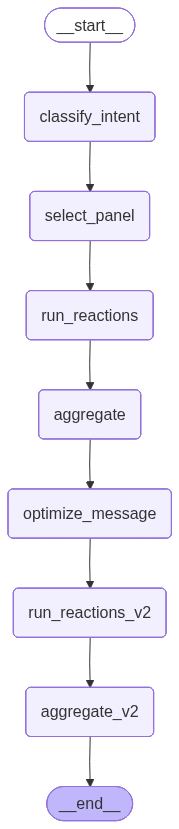

In [15]:
# Visualize the graph
from IPython.display import Image, display

try:
    img = focus_group_graph.get_graph().draw_mermaid_png()
    display(Image(img))
except Exception as e:
    # Fallback: print mermaid text
    print("Graph visualization (paste into mermaid.live):")
    print(focus_group_graph.get_graph().draw_mermaid())

## 10. Test Runs

Run the graph with different inputs — the classifier routes automatically.

In [16]:
# --- TEST: Localization (active) ---

# Langfuse v4: wrap in context manager for trace metadata, then pass handler to graph
trace_id = f"maplepulse-{uuid.uuid4().hex[:8]}"

t_total = time.time()

with lf.start_as_current_observation(
    name="focus-group-localization",
    metadata={"pipeline": "v1_langgraph", "version": "1.1", "panel_size": 20},
) as trace:
    langfuse_handler = make_langfuse_handler()

    result = await focus_group_graph.ainvoke(
        {
            "user_input": """Test this for localisation - Stop leaving money on the table. Earn up to 3% cashback on every Tim Hortons run and gas station fill-up. Whether you're t
        apping your card at the local rink or sending an e-Transfer to a friend, our rewards work as hard as you do. 
        Sign up for the NorthStar Card and get your first $50 bonus—straight to your account in real-time..""",
            "panel_size": 20,
            "panel_seed": 789,
        },
        config={"callbacks": [langfuse_handler]},
    )

total_elapsed = time.time() - t_total

# --- Timing Summary ---
timings = result.get("timings", {})
timings["total"] = round(total_elapsed, 2)

print(f"\n{'='*60}")
print(f"PERFORMANCE SUMMARY")
print(f"{'='*60}")
print(f"  {'Node':<25s}  {'Time':>8s}  {'% of Total':>10s}")
print(f"  {'-'*45}")
for node, secs in sorted(timings.items(), key=lambda x: x[1], reverse=True):
    pct = (secs / total_elapsed * 100) if total_elapsed > 0 else 0
    print(f"  {node:<25s}  {secs:>7.1f}s  {pct:>9.0f}%")
print(f"  {'-'*45}")
print(f"  {'TOTAL':<25s}  {total_elapsed:>7.1f}s")
print(f"{'='*60}")
print(f"\nLangfuse trace: {lf.get_current_trace_id() or trace_id}")
print(f"View at: {os.environ.get('LANGFUSE_HOST', 'https://cloud.langfuse.com')}")

Classification: localization (confidence: 95%) [7.9s]
Reasoning: User explicitly asks to "Test this for localisation" and provides a single piece of marketing copy (tagline/ad body). This matches the localization use case (one message to evaluate across regions), not an A/B test, survey, or product concept.
Panel selected: 20 personas from 6 provinces
  84  Quebec                Retired
  73  Ontario               Retired
  41  British Columbia      Purchasing Agent
  62  Quebec                Cybersecurity Analyst
  55  Ontario               Interior Designer
  26  Ontario               Heavy Equipment Operator
  27  Ontario               Compliance Officer
  58  Quebec                Person with disability (not working)
  66  Ontario               Retired
  77  Quebec                Retired
  56  New Brunswick         IT Project Manager
  50  Ontario               Retired
  53  Alberta               HVAC Technician
  24  Ontario               Human Resources Manager
  33  Quebec     

Failed to detach context
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/site-packages/opentelemetry/context/__init__.py", line 155, in detach
    _RUNTIME_CONTEXT.detach(token)
  File "/usr/local/lib/python3.12/site-packages/opentelemetry/context/contextvars_context.py", line 53, in detach
    self._current_context.reset(token)
ValueError: <Token var=<ContextVar name='current_context' default={} at 0x7b3ec5665210> at 0x7b3e8dcfddc0> was created in a different Context
Context error: No active span in current context. Operations that depend on an active span will be skipped. Ensure spans are created with start_as_current_observation() or that you're operating within an active span context.


Done in 42.5s — 20 OK, 0 errors

PERSONA REACTIONS — ROUND 2 (OPTIMIZED MESSAGE)

  84 | Quebec          | Drummondville
  > "Looks handy for Tim Hortons runs and gas, that $50 bonus sounds nice, but at 84 I dont do tapping or e-Transfers much, and is 'Canada-wide support' available in French? Also where are the fees, tho?"

  73 | Ontario         | Toronto
  > "Oh that sounds great, I’m at Tim’s all the time and the rink/e-Transfer perks feel very Canadian. 3% cashback and $50 now is tempting, but I’d wanna know about fees or limits first, seems a bit too good to be true."

  41 | British Columbia | Vancouver
  > "Not bad, I do Tim Hortons every day so 3% back sounds sweet, and rink taps/e-Transfer rewards are kinda cool. $50 bonus is tempting but I alwys worry about the fine print despite 'clear terms'. Hoping no sneaky fees or high APR tho."

  62 | Quebec          | Montreal
  > "Ok thats actually tempting, Tims + gas cashback sounds useful with rising costs, and $50 right away is 

In [17]:
# --- WIP: Product Concept (not yet implemented) ---
# result_product = await focus_group_graph.ainvoke({
#     "user_input": """SnowShare — A peer-to-peer snow removal marketplace...""",
#     "panel_size": 15,
#     "panel_seed": 99,
# })

In [18]:
# --- WIP: A/B Copy Test (not yet implemented) ---
# result_ab = await focus_group_graph.ainvoke({
#     "user_input": """Version A: ... Version B: ...""",
#     "panel_size": 15,
#     "panel_seed": 123,
# })

In [19]:
# --- WIP: Survey Pre-Test (not yet implemented) ---
# result_survey = await focus_group_graph.ainvoke({
#     "user_input": """On a scale of 1-5, how likely are you to...""",
#     "panel_size": 15,
#     "panel_seed": 456,
# })

## 11. Save Results & Flush Traces

In [20]:
output_dir = Path("../data/experiments")
output_dir.mkdir(parents=True, exist_ok=True)

timestamp = time.strftime("%Y%m%d_%H%M%S")

# --- Save full results JSON (per-run snapshot) ---
out_path = output_dir / f"langgraph_run_{timestamp}.json"
save_data = {
    "input": {
        "original_message": result["user_input"],
        "optimized_message": result.get("optimized_input", ""),
        "optimization_changes": result.get("optimization_changes", []),
    },
    "round_1": {
        "summary": result.get("summary", {}),
        "reactions": result.get("results", []),
    },
    "round_2": {
        "summary": result.get("summary_v2", {}),
        "reactions": result.get("results_v2", []),
    },
    "timings": timings,
}
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(save_data, f, indent=2, ensure_ascii=False, default=str)

# --- Append to performance log CSV (tracks all runs over time) ---
perf_log_path = output_dir / "performance_log.csv"
r1_meta = result.get("summary", {}).get("_metadata", {})
r2_meta = result.get("summary_v2", {}).get("_metadata", {})

perf_row = {
    "timestamp": timestamp,
    "panel_size": len(result.get("panel", [])),
    "model": DEFAULT_MODEL,
    "classify_s": timings.get("classify_intent", ""),
    "reactions_r1_s": timings.get("reactions_r1", ""),
    "optimize_s": timings.get("optimize_message", ""),
    "reactions_r2_s": timings.get("reactions_r2", ""),
    "total_s": timings.get("total", ""),
    "r1_avg_sentiment": r1_meta.get("avg_sentiment_score", ""),
    "r1_resonance_pct": r1_meta.get("resonance_pct", ""),
    "r2_avg_sentiment": r2_meta.get("avg_sentiment_score", ""),
    "r2_resonance_pct": r2_meta.get("resonance_pct", ""),
    "sentiment_delta": round(r2_meta.get("avg_sentiment_score", 0) - r1_meta.get("avg_sentiment_score", 0), 1) if r1_meta and r2_meta else "",
    "r1_errors": sum(1 for r in result.get("results", []) if "error" in r),
    "r2_errors": sum(1 for r in result.get("results_v2", []) if "error" in r),
    "notes": "",  # fill in manually for architecture changes, model swaps, etc.
}

perf_df = pd.DataFrame([perf_row])
write_header = not perf_log_path.exists()
perf_df.to_csv(perf_log_path, mode="a", header=write_header, index=False)

# Flush Langfuse traces
lf.flush()

r1_count = len(result.get("results", []))
r2_count = len(result.get("results_v2", []))
print(f"Saved to {out_path}")
print(f"  Round 1: {r1_count} reactions | Round 2: {r2_count} reactions")
print(f"  Optimized message + changes included")
print(f"  Timings included: {list(timings.keys())}")
print(f"\nPerformance log: {perf_log_path}")
if not write_header:
    prev = pd.read_csv(perf_log_path)
    print(f"  Total runs logged: {len(prev)}")
    if len(prev) > 1:
        last = prev.iloc[-2]
        curr_total = timings.get("total", 0)
        prev_total = last.get("total_s", 0)
        if prev_total and curr_total:
            delta = curr_total - prev_total
            print(f"  vs previous run: {delta:+.1f}s ({delta/prev_total*100:+.0f}%)")
print(f"\nLangfuse traces flushed")

Saved to ../data/experiments/langgraph_run_20260319_100511.json
  Round 1: 20 reactions | Round 2: 20 reactions
  Optimized message + changes included
  Timings included: ['classify_intent', 'reactions_r1', 'optimize_message', 'reactions_r2', 'total']

Performance log: ../data/experiments/performance_log.csv
  Total runs logged: 5
  vs previous run: +53.1s (+69%)

Langfuse traces flushed
